### **Calculating physico-chemical properties**

Currently available calculations: https://apidocs.chemaxon.com/python_api/apidocs/chemaxon/calculations.html

In [12]:
from chemaxon.io import import_mol
from chemaxon.calculations import logp, logd, pka, hlb

mol = import_mol('CC(=O)NC1=CC=C(O)C=C1') # paracetamol

print('logP:        ', logp(mol))
print('logD[pH 9.0]:', logd(mol, ph=9.0))
print('pKa:         ', pka(mol))
print('hlb:         ', hlb(mol))

logP:         0.92
logD[pH 9.0]: 0.8
pKa:          [atom: 3,  pka: 16.65 (ACIDIC)], [atom: 8,  pka: 9.46 (ACIDIC)], [atom: 2,  pka: -4.36 (BASIC)], [atom: 8,  pka: -5.94 (BASIC)]
hlb:          14.14


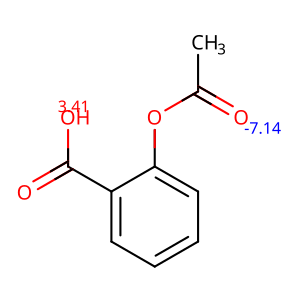

In [13]:
from chemaxon.io import import_mol
from chemaxon.calculations import pka

mol = import_mol('aspirin')

pka_result = pka(mol)
pka_result.mol

### **Visualizing atom-index-based results**

Many calculations return a value for every atom (e.g. `pka_result.pka_values` above).
Function `visualize_atom_values` renders such per-atom results as an SVG image placing each
value next to its atom. Required parameters are the molecule and the result list. The result list 
should consist of objects containing an `atom_index` field and one or more fields containing int or double results. Since `pka_values`
isn't rounded, it can be rounded by setting the `precision` parameter (default value is `2`).

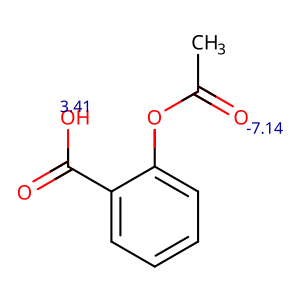

In [14]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values
from chemaxon.calculations import AtomDoubleValue

SVG(visualize_atom_values(mol,  pka_result.pka_values, precision=2))

When the result list carries more than one value per atom (e.g. `ChargeValue` has both
`formal_charge` and `total_charge`), the `value_attribute` parameter should be used to pick the one to display:

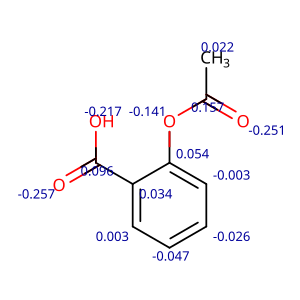

In [15]:
from chemaxon.calculations import charge_by_atoms, ChargeValue

charge_result = charge_by_atoms(mol)
SVG(visualize_atom_values(mol, charge_result.charge_values, value_attribute='total_charge', precision=3))

Visualized result can be exported to svg file as well using standard python functions: 

In [16]:
svg_content = visualize_atom_values(mol, charge_result.charge_values, value_attribute='total_charge', precision=3)
with open("aspirinCharge.svg", "w") as f: f.write(svg_content)

In [ ]:
import sys

!{sys.executable} -m pip install matplotlib

Text(0, 0.5, 'logD')

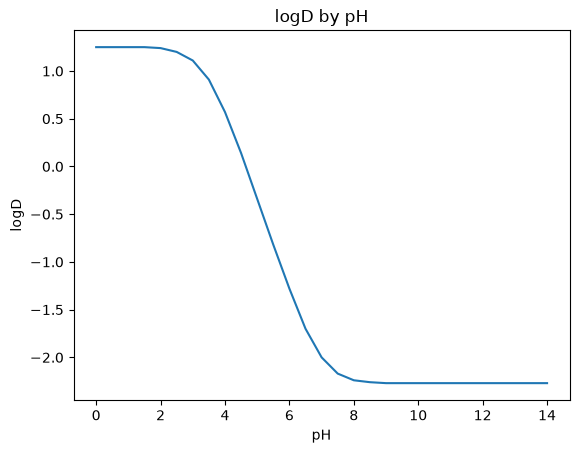

In [10]:
from chemaxon.calculations import logd_ph_range, PhRange
import matplotlib.pyplot as pyplt

res = logd_ph_range(import_mol('aspirin'), PhRange(0, 14, 0.5))
pyplt.plot([r.ph for r in res],[r.logd for r in res])
pyplt.title('logD by pH')
pyplt.xlabel('pH')
pyplt.ylabel('logD')

### **Chemical Terms**

Please note that Chemaxon Python API **does not support** all available [Chemical Terms](https://docs.chemaxon.com/display/docs/chemical-terms_functions-by-categories.md) functions. Check the documentation for details.

In [11]:
from chemaxon.calculations import evaluate

print('Formula:   ', evaluate(mol, 'formula()'))
print('Atom count:', evaluate(mol, 'atomCount()'))
print('Ring count:', evaluate(mol, 'ringCount()'))
print('Fsp3:      ', evaluate(mol, 'fsp3()'))
print('logP:      ', evaluate(mol, 'logP()'))
print('logS:      ', evaluate(mol, 'logS()'))

Formula:    C9H8O4
Atom count: 21
Ring count: 1
Fsp3:       0.1111
logP:       1.2548
logS:       -1.8489


#### **Tautomer region of warfarin**

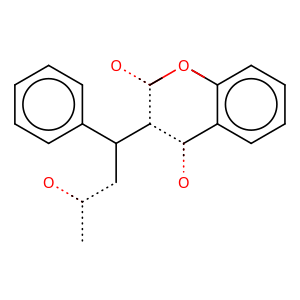

In [12]:
warfarin = import_mol('warfarin')
import_mol(evaluate(warfarin, 'molFormat(genericTautomer(), "smarts")'))

### **Calculating properties for a set of molecules**

In [ ]:
import sys

!{sys.executable} -m pip install pandas matplotlib

In [13]:
import pandas

mols = pandas.read_table('../nci1000.smiles', names=['SMILES', 'NCI_ID'])
mols

,SMILES,NCI_ID
0,CC1=CC(=O)C=CC1=O,1
1,S(SC1=NC2=CC=CC=C2S1)C3=NC4=C(S3)C=CC=C4,2
2,OC1=C(Cl)C=C(C=C1[N+]([O-])=O)[N+]([O-])=O,3
3,[O-][N+](=O)C1=CNC(=N)S1,4
4,NC1=CC2=C(C=C1)C(=O)C3=C(C=CC=C3)C2=O,5
...,...,...
995,OC(=O)CN(CC(O)=O)CC1=CC=CC=C1,1003
996,CC(C)N(CC(O)=O)CC(O)=O,1004
997,C1=CC=C(C=C1)C=NC(N=CC2=CC=CC=C2)C3=CC=CC=C3,1005
998,CC(C)(C)C[C]1(C)NC(=O)NC1=O,1006


In [14]:
mols['LOGP'] = mols.apply(lambda row: round(logp(import_mol(row['SMILES'])), 2), axis = 'columns')
mols['LOGD[3.0]'] = mols.apply(lambda row: logd(import_mol(row['SMILES']), ph=3.0), axis = 'columns')
mols['LOGD[7.4]'] = mols.apply(lambda row: logd(import_mol(row['SMILES']), ph=7.4), axis = 'columns')
mols['LOGD[11.0]'] = mols.apply(lambda row: logd(import_mol(row['SMILES']), ph=11.0), axis = 'columns')
mols

,SMILES,NCI_ID,LOGP,LOGD[3.0],LOGD[7.4],LOGD[11.0]
0,CC1=CC(=O)C=CC1=O,1,1.24,1.24,1.24,1.24
1,S(SC1=NC2=CC=CC=C2S1)C3=NC4=C(S3)C=CC=C4,2,6.22,6.22,6.22,6.22
2,OC1=C(Cl)C=C(C=C1[N+]([O-])=O)[N+]([O-])=O,3,2.15,1.96,0.25,0.25
3,[O-][N+](=O)C1=CNC(=N)S1,4,-0.22,-1.69,-0.27,-0.33
4,NC1=CC2=C(C=C1)C(=O)C3=C(C=CC=C3)C2=O,5,2.09,2.04,2.09,2.09
...,...,...,...,...,...,...
995,OC(=O)CN(CC(O)=O)CC1=CC=CC=C1,1003,-2.08,-2.08,-5.27,-6.17
996,CC(C)N(CC(O)=O)CC(O)=O,1004,-3.16,-3.92,-6.30,-6.31
997,C1=CC=C(C=C1)C=NC(N=CC2=CC=CC=C2)C3=CC=CC=C3,1005,5.72,5.72,5.72,5.72
998,CC(C)(C)C[C]1(C)NC(=O)NC1=O,1006,1.19,1.19,1.19,0.04


array([[<Axes: title={'center': 'LOGP'}>,
        <Axes: title={'center': 'LOGD[3.0]'}>],
       [<Axes: title={'center': 'LOGD[7.4]'}>,
        <Axes: title={'center': 'LOGD[11.0]'}>]], dtype=object)

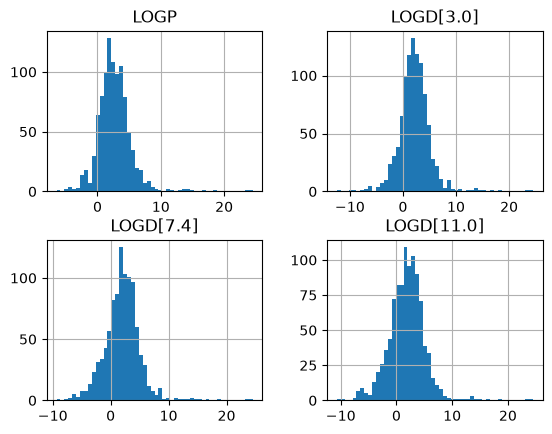

In [15]:
mols.hist(['LOGP', 'LOGD[3.0]', 'LOGD[7.4]', 'LOGD[11.0]'], bins=50)

### **ADMET predictors**

There are four endpoints available in the Chemaxon Python API falling into the ADMET predictions category: _herg_classifiaction_, _herg_activity_, _bbb_ (Blood-Brain Barrier) and _cns_mpo_ (CNS Multiparameter Optimisation).

In [16]:
from chemaxon.calculations import herg_classification, herg_activity, bbb, cns_mpo

print(str(mol), ' (aspirin)')
print()
print('HERG classification:', 'SAFE' if herg_classification(mol).classification == 0 else 'TOXIC')
print('HERG activity:      ', herg_activity(mol).value)
print('BBB score:          ', bbb(mol).score)
print('CNS MPO score:      ', cns_mpo(mol).score)

CC(=O)OC1=CC=CC=C1C(O)=O |c:6,8,t:4|  (aspirin)

HERG classification: SAFE
HERG activity:       3.788064026672559
BBB score:           4.050916887199017
CNS MPO score:       5.75


In [17]:
mols_admet = pandas.read_table('../nci50.smiles', names=['SMILES', 'NCI_ID'])

mols_admet['HERG classification'] = mols_admet.apply(lambda row: 'SAFE' if herg_classification(import_mol(row['SMILES'])).classification == 0 else 'TOXIC', axis = 'columns')
mols_admet['HERG activity'] = mols_admet.apply(lambda row: herg_activity(import_mol(row['SMILES'])).value, axis = 'columns')
mols_admet['BBB score'] = mols_admet.apply(lambda row: bbb(import_mol(row['SMILES'])).score, axis = 'columns')
mols_admet['CNS MPO score'] = mols_admet.apply(lambda row: cns_mpo(import_mol(row['SMILES'])).score, axis = 'columns')

mols_admet

,SMILES,NCI_ID,HERG classification,HERG activity,BBB score,CNS MPO score
0,CC1=CC(=O)C=CC1=O,1,SAFE,3.527087,4.402743,5.707000
1,S(SC1=NC2=CC=CC=C2S1)C3=NC4=C(S3)C=CC=C4,2,SAFE,5.288656,4.511565,3.289000
2,OC1=C(Cl)C=C(C=C1[N+]([O-])=O)[N+]([O-])=O,3,SAFE,3.994468,2.900463,5.199667
3,[O-][N+](=O)C1=CNC(=N)S1,4,SAFE,3.931435,2.691684,5.500000
4,NC1=CC2=C(C=C1)C(=O)C3=C(C=CC=C3)C2=O,5,SAFE,4.450256,5.024654,5.455111
5,OC(=O)C1=C(C=CC=C1)C2=C3C=CC(=O)C(=C3OC4=C2C=C...,6,SAFE,4.978091,3.096815,3.817072
6,CN(C)C1=C(Cl)C(=O)C2=C(C=CC=C2)C1=O,7,SAFE,3.972201,5.246618,5.869000
7,CC1=C(C2=C(C=C1)C(=O)C3=CC=CC=C3C2=O)[N+]([O-])=O,8,SAFE,4.716067,4.873092,5.111222
8,CC(=NO)C(C)=NO,9,SAFE,3.536242,2.390943,5.500000
9,C1=CC=C(C=C1)P(C2=CC=CC=C2)C3=CC=CC=C3,10,SAFE,5.191467,2.189764,3.000000


Filter out the TOXIC compounds based on their hERG classification.

In [14]:
mols_admet.filter(items=['SMILES', 'NCI_ID', 'HERG classification', 'HERG activity']).query('`HERG classification` == "TOXIC"')

,SMILES,NCI_ID,HERG classification,HERG activity
12,NC1=CC=NC2=C1C=CC(=C2)Cl,13,TOXIC,5.067218
13,CCCCCC[CH]1CCCCN1,14,TOXIC,5.536671
40,CN(C)[CH](C1=CC=CC=C1)C2=C(C)C=CC=C2,41,TOXIC,5.476099


### **Isoelectric point calculation**

In [18]:
from chemaxon.calculations import isoelectric_point

glycine_mol = import_mol('C(C(=O)O)N')

res = isoelectric_point(glycine_mol)

print('Isoelectric point of glycine: ', res.isoelectric_point)
print('Charge distributions: \n', res.charge_distributions)
print()

Isoelectric point of glycine:  5.7764474458532655
Charge distributions: 
 [IsoelectricChargeResult(charge=0.9950975988329285, ph=0.0), IsoelectricChargeResult(charge=0.9846598571913905, ph=0.5), IsoelectricChargeResult(charge=0.9530476031965848, ph=1.0), IsoelectricChargeResult(charge=0.8652081089245873, ph=1.5), IsoelectricChargeResult(charge=0.6699470037872222, ph=2.0), IsoelectricChargeResult(charge=0.39094357485128406, ph=2.5), IsoelectricChargeResult(charge=0.16873158347385953, ph=3.0), IsoelectricChargeResult(charge=0.06031498852059858, ph=3.5), IsoelectricChargeResult(charge=0.01988860103811574, ph=4.0), IsoelectricChargeResult(charge=0.00635972354141523, ph=4.5), IsoelectricChargeResult(charge=0.001968209077158334, ph=5.0), IsoelectricChargeResult(charge=0.0004596767143161262, ph=5.5), IsoelectricChargeResult(charge=-0.0003717231072617455, ph=6.0), IsoelectricChargeResult(charge=-0.001750806299997576, ph=6.5), IsoelectricChargeResult(charge=-0.0056967698521620536, ph=7.0), Isoe

In [16]:
from chemaxon.calculations import PhRange

res = isoelectric_point(glycine_mol, ph_range=PhRange(0, 14, 0.5))

rows = []
for charge_res in res.charge_distributions:
    rows.append({'pH': charge_res.ph, 'Charge distribution': charge_res.charge})

df_isoelectric = pandas.DataFrame(rows)
df_isoelectric

,pH,Charge distribution
0,0.0,0.995098
1,0.5,0.984660
2,1.0,0.953048
3,1.5,0.865208
4,2.0,0.669947
5,2.5,0.390944
6,3.0,0.168732
7,3.5,0.060315
8,4.0,0.019889
9,4.5,0.006360


<Axes: title={'center': 'Charge Distribution vs pH for Glycine'}, xlabel='pH'>

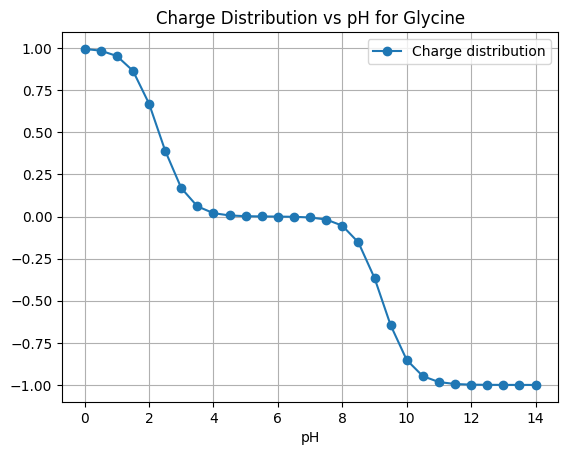

In [51]:
#!{sys.executable} -m pip install matplotlib

import matplotlib

df_isoelectric.plot(x='pH', y='Charge distribution', kind='line', marker='o', title='Charge Distribution vs pH for Glycine', grid=True)

### **Conformer calculation**

Showing the 5 lowest-energy conformers out of 100 generated:


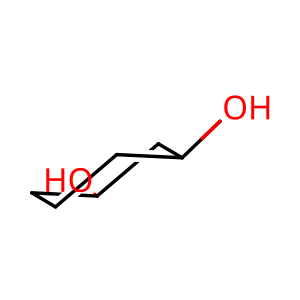

11.50232067802384


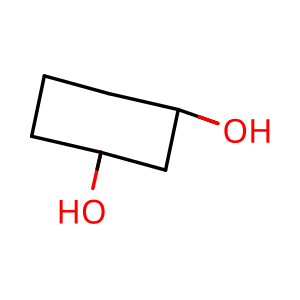

11.513745213085235


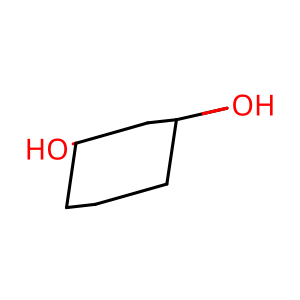

11.514176889006993


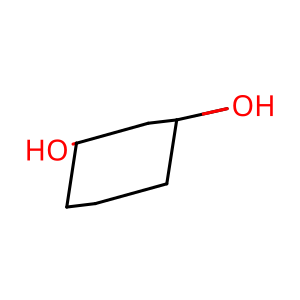

11.516465444053912


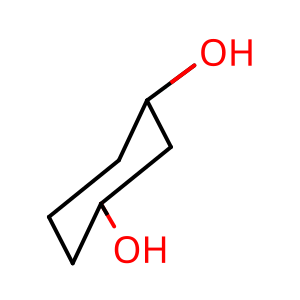

11.568504069248455


In [1]:
#helper function to show the result of the conformer calculation
def display_result(result: list):
    for res in result:
        display(res[0])
        print(res[1])
        
from chemaxon.io import import_mol
from chemaxon.calculations import conformers

mol = import_mol('OC1CC(O)CCC1')
result = conformers(mol)

TOP_N = 5
top_conformers = sorted(result, key=lambda r: r[1])[:TOP_N]
print(f'Showing the {len(top_conformers)} lowest-energy conformers out of {len(result)} generated:')
display_result(top_conformers)

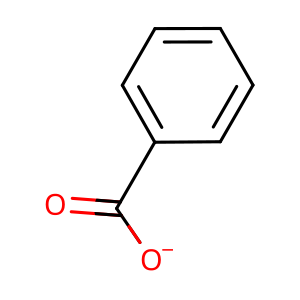

184.20114759569609


In [56]:
from chemaxon.calculations import ConformerOptions, ConformerForceField, EnergyUnit, OptimizationLimit

options = ConformerOptions()
options.max_number_of_conformers = 3
options.energy_unit = EnergyUnit.KJ_PER_MOL
options.force_field = ConformerForceField.MMFF94
options.optimization_limit = OptimizationLimit.VERY_STRICT
result = conformers(mol, options=options)
display_result(result)

### **Solubility calculation**

In [22]:
from chemaxon.io import import_mol
from chemaxon.calculations import solubility

mol_str = 'CC(=O)OC1=CC=CC=C1C(O)=O'
mol = import_mol(mol_str)
solubility(mol)

-1.8489350401969602

In [15]:
from chemaxon.calculations import solubility_ph_range, PhRange, SolubilityUnit

result = solubility_ph_range(mol, PhRange(0.0, 14.0, 1.0), unit = SolubilityUnit.MOL_PER_L)
rows = []
for res in result:
    rows.append({'pH': res.ph, 'Solubility': res.solubility})

df_solubility = pandas.DataFrame(rows)
df_solubility

,pH,Solubility
0,0.0,0.014166
1,1.0,0.014215
2,2.0,0.014705
3,3.0,0.019608
4,4.0,0.068644
5,5.0,0.558996
6,6.0,1.416006
7,7.0,1.416006
8,8.0,1.416006
9,9.0,1.416006


### **Tautomer calculation**

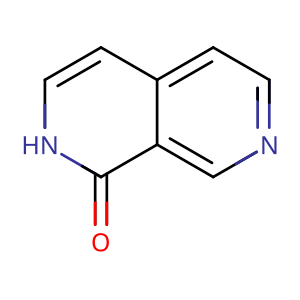

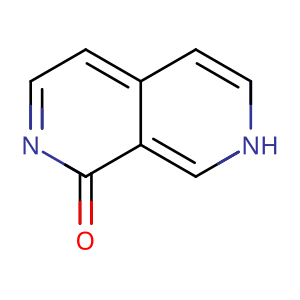

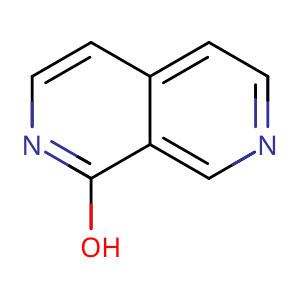

In [8]:
from chemaxon.io import import_mol 
from chemaxon.calculations import (all_tautomers, dominant_tautomer_distribution, 
    canonical_tautomer, major_tautomer, TautomerAdvancedOptions)

mol = import_mol('OC1=NC=CC2=CC=NC=C12')
result = all_tautomers(mol)
for res in result:
    display(res)

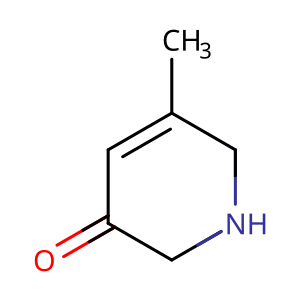

98.77065813615263


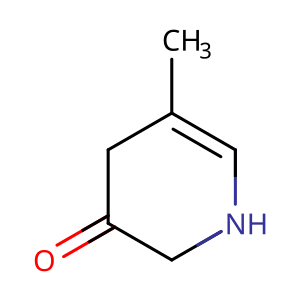

1.2293414950976624


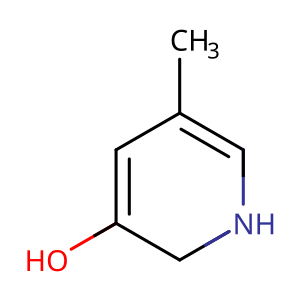

3.687497028338006e-07


In [9]:
#helper function to show the result of tautomer calculation
def display_tautomer_result(result: list):
    for res in result:
        display(res[0])
        print(res[1])

mol = import_mol('CC1=CNCC(O)=C1')
result = dominant_tautomer_distribution(mol)
display_tautomer_result(result)

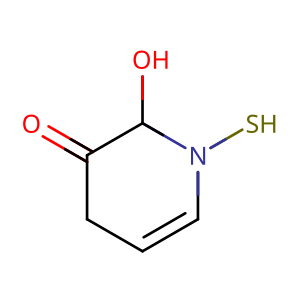

In [10]:
mol = import_mol('OC1N(S)CC=CC1=O')
canonical_tautomer(mol, normal=True)

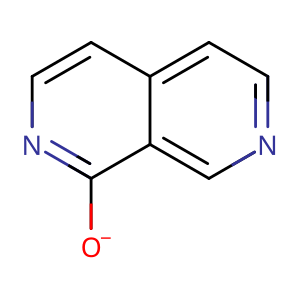

In [11]:
mol = import_mol('OC1=NC=CC2=CC=NC=C12')
major_tautomer(mol, ph=14.0)

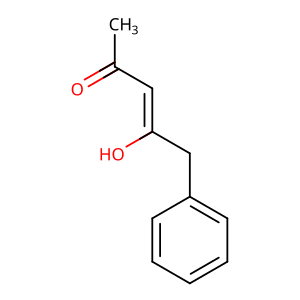

In [12]:
mol = import_mol('CC(=O)\\C=C(/O)CC1=CC=CC=C1')
advanced_options = TautomerAdvancedOptions()
advanced_options.protect_double_bond_stereo = True
major_tautomer(mol, options=advanced_options)

### **Resonance calculation**

The resonance plugin enumerates the resonant (mesomeric) structures of a molecule — the set of
Lewis structures that differ only in the distribution of the electrons, not in the position of the
atoms. By default `resonance_structures` returns only the *major contributors*, filters out
symmetrical duplicates and generates at most 1000 structures.

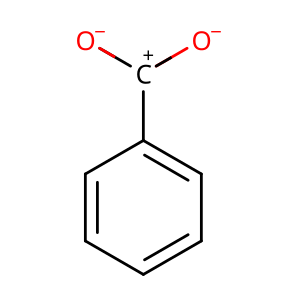

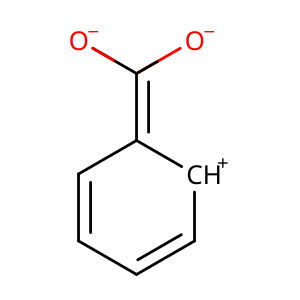

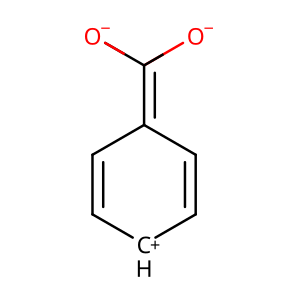

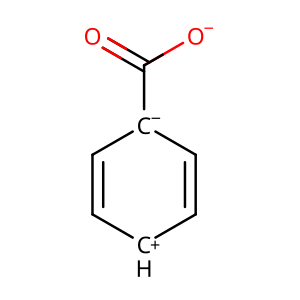

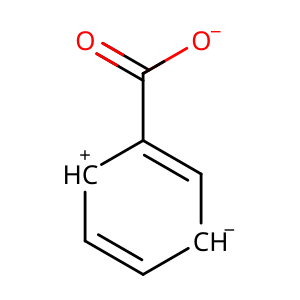

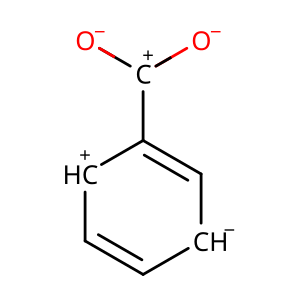

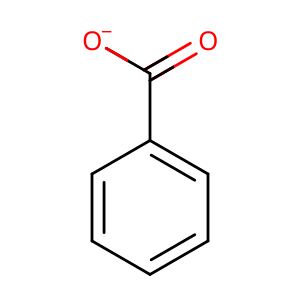

In [23]:
from chemaxon.io import import_mol
from chemaxon.calculations import resonant_structures, canonical_resonant_structure

mol = import_mol('[O-]C(=O)C1=CC=CC=C1')
result = resonant_structures(mol)
for res in result:
    display(res)

Pass `major_contributors_only=False` to obtain every contributor, and `symmetry_filtering=False`
to keep symmetrical duplicates. `max_structures` caps the number of generated structures.

In [5]:
mol = import_mol('[O-]C(=O)C([O-])=O')
all_contributors = resonant_structures(mol, major_contributors_only=False, symmetry_filtering=False)
major_contributors = resonant_structures(mol)
print(f'{len(all_contributors)} contributors in total, {len(major_contributors)} of them major')

97 contributors in total, 3 of them major


`canonical_resonant_structure` returns a single, canonical representative form, which is useful
for example for structure indexing and searching. Set `clean_structure=True` to lay the result
out in 2D.

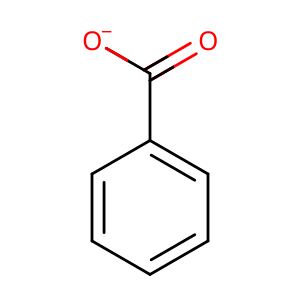

In [24]:
mol = import_mol('[O-]C(=O)C1=CC=CC=C1')
canonical_resonant_structure(mol, clean_structure=True)

### **Geometrical calculations**

#### Polar Surface Area (2D) 

For more information about this plugin, check the [public documentation](https://docs.chemaxon.com/latest/calculators_polar-surface-area-plugin-2d.html).

The molecule: (aspirin)


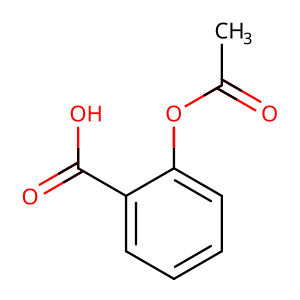

Polar Surface Area value: 63.6


In [25]:
from chemaxon.calculations import polar_surface_area

mol_psa = import_mol('CC(=O)OC1=CC=CC=C1C(O)=O')
psa_value = polar_surface_area(mol_psa)

print('The molecule: (aspirin)')
display(mol_psa)
print('Polar Surface Area value: ' + str(psa_value))

### **Hückel Analysis**

Several methods are available that are based on the Hückel Molecular Orbital (HMO) theorem/method. An example for each on a `chemaxon.Molecule` (these can also be calculated on specific pH values):

In [27]:
from IPython.display import SVG
from chemaxon.calculations import (hmo_electrophilic_localization_energy,
                                    hmo_nucleophilic_localization_energy, hmo_electron_density,
                                    hmo_charge_density, hmo_electrophilic_order,
                                    hmo_nucleophilic_order, hmo_pi_energy)
from chemaxon.io import import_mol, visualize_atom_values

mol_hmo = import_mol('CN1C=NC2=C1C(=O)NC(=O)N2C')

electr_localization_energy = hmo_electrophilic_localization_energy(mol_hmo)
nucleo_localization_energy = hmo_nucleophilic_localization_energy(mol_hmo)
electr_dens = hmo_electron_density(mol_hmo)
ch_dens = hmo_charge_density(mol_hmo)
electr_ord = hmo_electrophilic_order(mol_hmo)
nucl_ord = hmo_nucleophilic_order(mol_hmo)
pi_energy = hmo_pi_energy(mol_hmo)

print('Pi energy: '+ str(pi_energy))

Pi energy: 23.18


L(+) localization energy by atom indices:


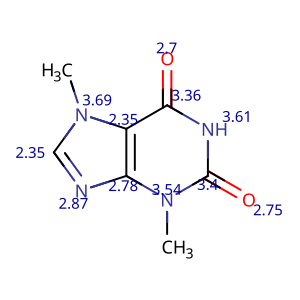

In [28]:
print('L(+) localization energy by atom indices:')
SVG(visualize_atom_values(mol_hmo, electr_localization_energy))

L(-) localization energy by atom indices:


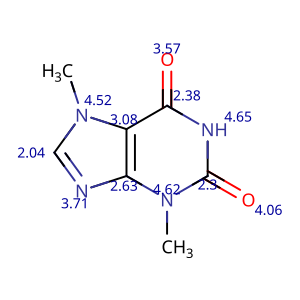

In [29]:
print('L(-) localization energy by atom indices:')
SVG(visualize_atom_values(mol_hmo, nucleo_localization_energy))

Electrophilic densities by atom indices:


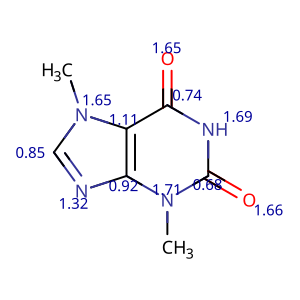

In [30]:
print('Electrophilic densities by atom indices:')
SVG(visualize_atom_values(mol_hmo, electr_dens))

Charge densities by atom indices:


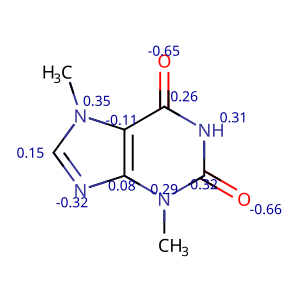

In [31]:
print('Charge densities by atom indices:')
SVG(visualize_atom_values(mol_hmo, ch_dens))

E(+) orders by atom indices:


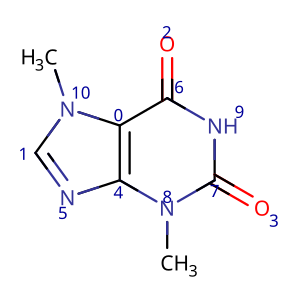

In [32]:
print('E(+) orders by atom indices:')
SVG(visualize_atom_values(mol_hmo, electr_ord))

Nu(-) orders by atom indices:


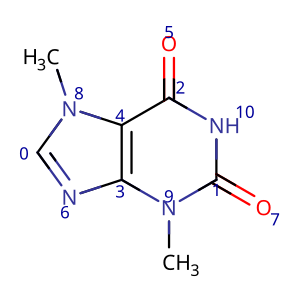

In [27]:
print('Nu(-) orders by atom indices:')
SVG(visualize_atom_values(mol_hmo, nucl_ord))

### **Molecular Surface Area 3D**

There are two versions available for 3D molecular surface area calculation:
- [van der Waals molecular surface area](https://docs.chemaxon.com/latest/calculators_molecular-surface-area-plugin-3d.html)
- [solvent accessible molecular surface area](https://docs.chemaxon.com/latest/calculators_molecular-surface-area-plugin-3d.html)

In [33]:
from chemaxon.io import import_mol, export_mol
from chemaxon.calculations import van_der_waals_surface_area, solvent_accessible_surface_area

aspirin = import_mol('CC(=O)OC1=CC=CC=C1C(O)=O')
vdw_result = van_der_waals_surface_area(aspirin)
asa_result = solvent_accessible_surface_area(aspirin)

print('van der Waals surface area of aspirin: ' + str(vdw_result.surface_area))
print('ASA surface area of aspirin: ' + str(asa_result.surface_area))
print('ASA of atoms with positive partial charge: ' + str(asa_result.asa_plus))
print('ASA of atoms with negative partial charge: ' + str(asa_result.asa_negative))
print('ASA of hydrophobic atoms (|partial charge| < 0.125): ' + str(asa_result.asa_hydrophobic))
print('ASA of polar atoms (|partial charge| >= 0.125): ' + str(asa_result.asa_polar))

van der Waals surface area of aspirin: 255.2
ASA surface area of aspirin: 387.94
ASA of atoms with positive partial charge: 249.15
ASA of atoms with negative partial charge: 138.79
ASA of hydrophobic atoms (|partial charge| < 0.125): 291.29
ASA of polar atoms (|partial charge| >= 0.125): 96.66


van der Waals increments of aspirin:


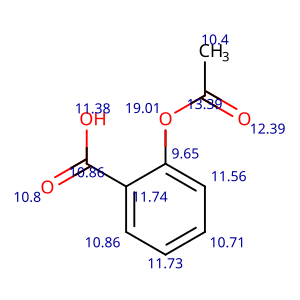

In [34]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('van der Waals increments of aspirin:')
SVG(visualize_atom_values(aspirin, vdw_result.increments))

### **Refractivity calculation**

Molar refractivity is a descriptor of the molecular volume and the London dispersive forces playing a role in drug-receptor interactions. For more information, check the [public documentation](https://docs.chemaxon.com/latest/calculators_refractivity-plugin.html).

The molecule: (aspirin)


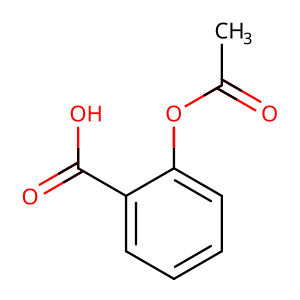

Molar refractivity: 44.45


In [38]:
from chemaxon.io import import_mol
from chemaxon.calculations import refractivity

mol_refr = import_mol('CC(=O)OC1=CC=CC=C1C(O)=O')  # aspirin

result = refractivity(mol_refr)

print('The molecule: (aspirin)')
display(mol_refr)
print('Molar refractivity:', result.molar_refractivity)

Atomic refractivity increments:


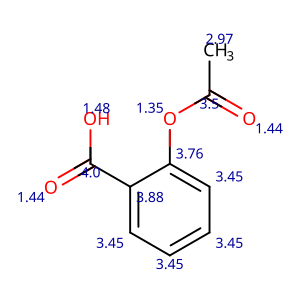

In [39]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('Atomic refractivity increments:')
SVG(visualize_atom_values(mol_refr, result.refractivity_values, value_attribute='refractivity'))

Atomic hydrogen refractivity increments:


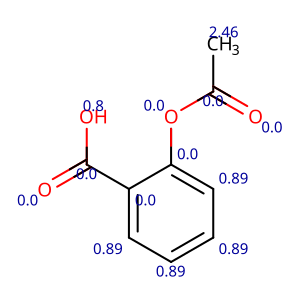

In [40]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('Atomic hydrogen refractivity increments:')
SVG(visualize_atom_values(mol_refr, result.refractivity_values, value_attribute='hydrogen_refractivity'))

### **Geometrical Descriptors calculation**

Molecule-scope 3D descriptors of a conformation (Dreiding and MMFF94 strain energy, minimal/maximal projection area and radius, minZ/maxZ, van der Waals volume), plus atom-level distance/angle/dihedral measurements and per-atom steric hindrance. A 3D conformer is generated automatically for input without 3D coordinates. For more information, check the [public documentation](https://docs.chemaxon.com/latest/calculators_geometrical-descriptors-plugin.html).

The molecule: (aspirin)


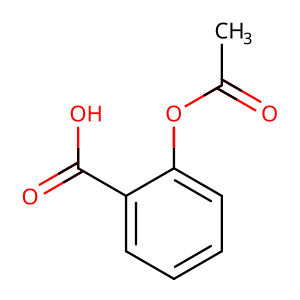

Dreiding energy: 29.78
MMFF94 energy: 42.36
Minimal projection area: 33.28
Maximal projection area: 56.0
Volume: 154.85


In [41]:
from chemaxon.io import import_mol
from chemaxon.calculations import geometrical_descriptors

mol_geom = import_mol('CC(=O)OC1=CC=CC=C1C(O)=O')  # aspirin

result = geometrical_descriptors(mol_geom)

print('The molecule: (aspirin)')
display(mol_geom)
print('Dreiding energy:', result.dreiding_energy)
print('MMFF94 energy:', result.mmff94_energy)
print('Minimal projection area:', result.minimal_projection_area)
print('Maximal projection area:', result.maximal_projection_area)
print('Volume:', result.volume)

The plugin also exposes standalone atom-level measurements (distance, angle, dihedral) and steric hindrance:

In [45]:
from chemaxon.calculations import distance, angle, dihedral, steric_hindrance

print('Distance between atom 0 and atom 1:', distance(mol_geom, 0, 1))
print('Angle at atom 1 (atoms 0-1-2):', angle(mol_geom, 0, 1, 2))
print('Dihedral of atoms 0-1-2-3:', dihedral(mol_geom, 0, 1, 2, 3))

Distance between atom 0 and atom 1: 6.11
Angle at atom 1 (atoms 0-1-2): 118.56
Dihedral of atoms 0-1-2-3: -178.6


Steric hindrance per atom:


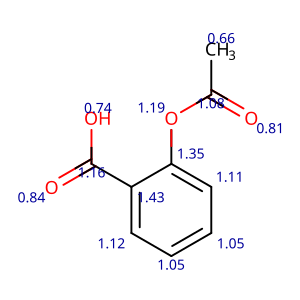

In [46]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('Steric hindrance per atom:')
SVG(visualize_atom_values(mol_geom, steric_hindrance(mol_geom)))

### **Structural Frameworks calculation**

Reduces a molecule to a structural framework (scaffold), such as the Bemis-Murcko scaffold or a ring system, by stripping side chains, generalizing atoms/bonds or selecting ring systems. For more information, check the [public documentation](https://docs.chemaxon.com/display/docs/calculators_structural-frameworks-plugin.html).

The molecule: (aspirin)


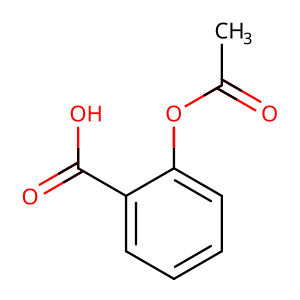

Bemis-Murcko framework:


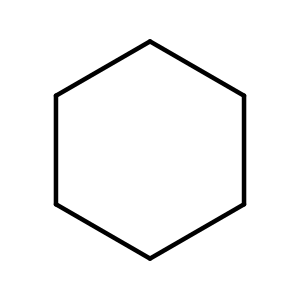

All ring systems:


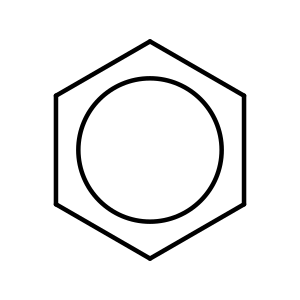

In [47]:
from chemaxon.io import import_mol
from chemaxon.calculations import structural_framework, FrameworkType

mol_scaffold = import_mol('CC(=O)OC1=CC=CC=C1C(O)=O')  # aspirin

print('The molecule: (aspirin)')
display(mol_scaffold)

bemis_murcko = structural_framework(mol_scaffold, framework_type=FrameworkType.BEMIS_MURCKO)
print('Bemis-Murcko framework:')
display(bemis_murcko)

ring_systems = structural_framework(mol_scaffold, framework_type=FrameworkType.ALL_RING_SYSTEMS)
print('All ring systems:')
display(ring_systems)

### **Hydrogen Bond Donor/Acceptor (HBDA) calculation**

For more information, check the [public documentation](https://docs.chemaxon.com/latest/calculators_hydrogen-bond-donor-acceptor-plugin.html).

The molecule: (paracetamol)


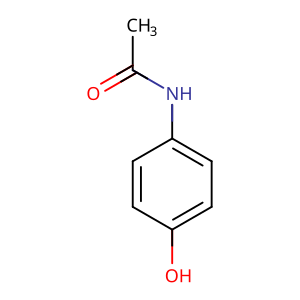

Donor atom count: 2
Acceptor atom count: 2
Donor site count: 2
Acceptor site count: 4


In [52]:
from chemaxon.io import import_mol
from chemaxon.calculations import hbda

mol_hbda = import_mol('CC(=O)NC1=CC=C(O)C=C1')  # paracetamol

result = hbda(mol_hbda)

print('The molecule: (paracetamol)')
display(mol_hbda)
print('Donor atom count:', result.donor_atom_count)
print('Acceptor atom count:', result.acceptor_atom_count)
print('Donor site count:', result.donor_site_count)
print('Acceptor site count:', result.acceptor_site_count)

Per-atom donor counts:


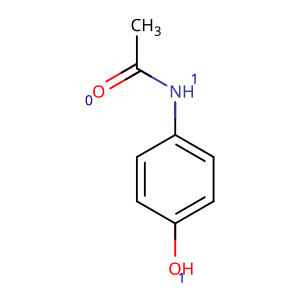

In [53]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('Per-atom donor counts:')
SVG(visualize_atom_values(mol_hbda, result.atom_values, value_attribute='donor_count'))

Per-atom acceptor counts:


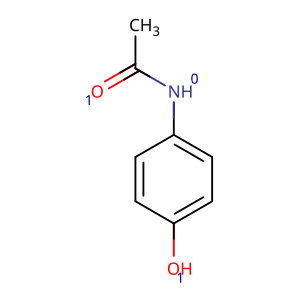

In [55]:
from IPython.display import SVG
from chemaxon.io import visualize_atom_values

print('Per-atom acceptor counts:')
SVG(visualize_atom_values(mol_hbda, result.atom_values, value_attribute='acceptor_count'))

The donor/acceptor counts can also be calculated for the major microspecies over a pH range:

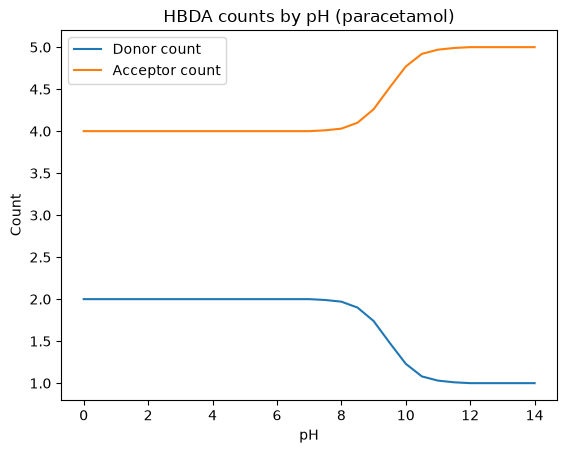

In [49]:
from chemaxon.calculations import hbda_ph_range, PhRange
import matplotlib.pyplot as pyplt

ph_results = hbda_ph_range(mol_hbda, PhRange(0, 14, 0.5))
pyplt.plot([r.ph for r in ph_results], [r.donor_count for r in ph_results], label='Donor count')
pyplt.plot([r.ph for r in ph_results], [r.acceptor_count for r in ph_results], label='Acceptor count')
pyplt.title('HBDA counts by pH (paracetamol)')
pyplt.xlabel('pH')
pyplt.ylabel('Count')
pyplt.legend()